In [14]:
%pip install matplotlib
%pip install scqubits
%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# SCQubits GUI

In [ ]:
import scqubits as scq
import matplotlib.pyplot as plt
import numpy as np
import math
scq.GUI()

Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

# Beginning(Hamiltonian)

In [23]:
Ej = 18 #GHz
Ec = 0.15 #GHz
ng = 0
n_cut = 5 #Number of extra Cooper pairs

transmon = scq.Transmon(Ej, Ec, ng, n_cut)
ham = transmon.hamiltonian()
ham


array([[15. , -9. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [-9. ,  9.6, -9. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. , -9. ,  5.4, -9. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. , -9. ,  2.4, -9. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. , -9. ,  0.6, -9. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. , -9. ,  0. , -9. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. , -9. ,  0.6, -9. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. , -9. ,  2.4, -9. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -9. ,  5.4, -9. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -9. ,  9.6, -9. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -9. , 15. ]])

### Eigenvalues

In [25]:
n_cut_2 = 30
levels = 6
transmon_v2 = scq.Transmon(Ej, Ec, ng, n_cut_2)
Eigen = transmon_v2.eigensys(evals_count=levels)
eigvals = Eigen[0]
print("Eigenvalues: ", eigvals)
energy = Eigen[0] + abs(Eigen[0][0])
print("Energy levels: ", energy)

Eigenvalues:  [-15.71434674 -11.22207412  -6.89264138  -2.73669472   1.23240932
   4.99737158]
Energy levels:  [ 0.          4.49227262  8.82170536 12.97765202 16.94675607 20.71171832]


# Plotting

### Energy Levels

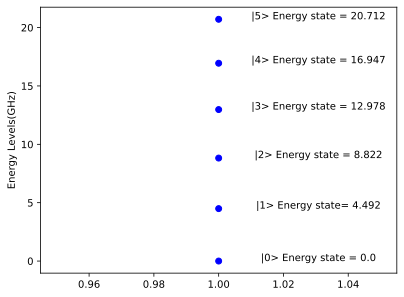

In [26]:
base = Eigen[0] + abs(Eigen[0][0])
rounded = []
for i in range(0,len(base)):
    rounded.append(round(base[i], 3))
Energy_levels = rounded


x = np.repeat([1], [levels])
y = Energy_levels

labels = [f"|0> Energy state = {Energy_levels[0]}", 
          f"|1> Energy state= {Energy_levels[1]}", 
          f"|2> Energy state = {Energy_levels[2]}", 
          f"|3> Energy state = {Energy_levels[3]}", 
          f"|4> Energy state = {Energy_levels[4]}", 
          f"|5> Energy state = {Energy_levels[5]}"]


fig, ax = plt.subplots()
ax.scatter(x, y, color='blue')

for i, label in enumerate(labels):
    ax.annotate(
        label,                      
        (x[i], y[i]),              
        textcoords="offset points", 
        xytext=(100, 0),            
        ha='center'
    )

plt.ylabel("Energy Levels(GHz)")
plt.show()

### Transiton Frequency(Formulaic)

Text(0, 0.5, 'Transition Frequency (GHz)')

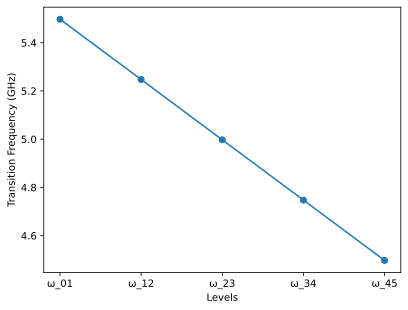

In [20]:
h = 6.626 #* 10**-34
hbar = h/(2*math.pi)

ωp = 1/hbar * (8*Ej*Ec)**0.5

def w_calc(n):
    return (ωp - (n+1) * Ec)

W01 = w_calc(1)
W12 = w_calc(2)
W23 = w_calc(3)
W34 = w_calc(4)
W45 = w_calc(5)

W = [W01, W12, W23, W34, W45]

Anharm = W12- W01
Pred_anharm = -Ec/hbar
Anharm_diff = Anharm-Pred_anharm

fig, ax = plt.subplots()
labels = ["ω_01", "ω_12", "ω_23", "ω_34", "ω_45"]
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(labels)
plt.scatter([1,2,3,4,5],W)
plt.plot([1,2,3,4,5], W)
plt.xlabel('Levels')
plt.ylabel('Transition Frequency (GHz)')

### Transition Frequency(Eigen)

Text(0, 0.5, 'Transition Frequency (GHz)')

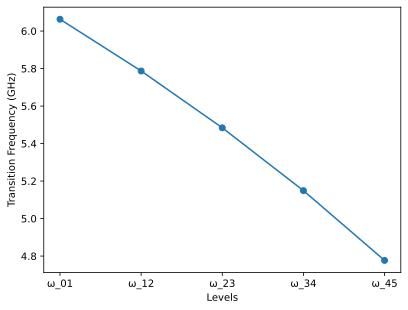

In [21]:
Change_energy = []
for i in range(0, levels-1):
    Change_energy.append(Energy_levels[i+1]-Energy_levels[i])

fig, ax = plt.subplots()
labels = ["ω_01", "ω_12", "ω_23", "ω_34", "ω_45"]
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(labels)
plt.scatter([1,2,3,4,5],Change_energy)
plt.plot([1,2,3,4,5],Change_energy)
plt.xlabel('Levels')
plt.ylabel('Transition Frequency (GHz)')